# Simple Benchmark Model

This notebook serves as a first baseline model for the Kaggle Competition.
It uses only the price data (OHLC) from the visible half of the trading session (the first 50 bars) to predict the price movement in the second half.

We will:
1. Load the training data (both seen and unseen halves).
2. Extract basic summary features from the first 50 bars for each session.
3. Calculate the target return from the final 50 bars.
4. Train a simple Random Forest Regressor on these features.
5. Generate predictions for the test set.

In [21]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, norm, probplot, skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="darkgrid")


## 1. Load Data

In [22]:
train_seen = pd.read_parquet('data/bars_seen_train.parquet')
train_unseen = pd.read_parquet('data/bars_unseen_train.parquet')
test_seen_public = pd.read_parquet('data/bars_seen_public_test.parquet')
test_seen_private = pd.read_parquet('data/bars_seen_private_test.parquet')
test_seen = pd.concat([test_seen_public, test_seen_private], ignore_index=True)

print(f"Train Sessions: {train_seen['session'].nunique()}")
print(f"Test Sessions: {test_seen['session'].nunique()}")


Train Sessions: 1000
Test Sessions: 20000


## 2. Feature Engineering
We will extract some simple time-series features from the first 50 bars:
- Total Return: End close / Start open
- Volatility: Standard deviation of close prices
- Max/Min ratios: High/low extremes relative to the final close of the seen chunk


In [23]:
from scipy.fft import rfft
import warnings
warnings.filterwarnings('ignore')

def calculate_rsi(prices, window=14):
    deltas = np.diff(prices)
    seed = deltas[:window+1]
    up = seed[seed >= 0].sum() / window
    down = -seed[seed < 0].sum() / window
    if down == 0:
        rs = np.inf
    else:
        rs = up/down
    res = [100. - 100./(1. + rs)]
    for i in range(window, len(prices)-1):
        delta = deltas[i]
        if delta > 0:
            upval = delta
            downval = 0.
        else:
            upval = 0.
            downval = -delta
        up = (up * (window - 1) + upval) / window
        down = (down * (window - 1) + downval) / window
        if down == 0:
            rs = np.inf
        else:
            rs = up/down
        res.append(100. - 100./(1. + rs))
    if len(res) == 0:
        return 50.0
    return res[-1]

def extract_features(df):
    features = []
    grouped = df.groupby('session')
    
    # Pre-calculate base arrays
    first_open = grouped['open'].first()
    last_close = grouped['close'].last()
    
    feat_df = pd.DataFrame(index=first_open.index)
    
    # 1. Period Returns
    feat_df['seen_return'] = (last_close / first_open) - 1.0
    feat_df['log_return'] = np.log(last_close) - np.log(first_open)
    
    # Volatility bounds
    feat_df['seen_volatility'] = grouped['close'].std()
    feat_df['max_high_ratio'] = grouped['high'].max() / last_close
    feat_df['min_low_ratio'] = grouped['low'].min() / last_close
    feat_df['high_low_spread'] = (grouped['high'].max() - grouped['low'].min()) / last_close
    
    # Per-session advanced features
    adv_features = []
    
    for session, data in grouped:
        close_prices = data['close'].values
        open_prices = data['open'].values
        high_prices = data['high'].values
        low_prices = data['low'].values
        
        returns = np.diff(close_prices) / close_prices[:-1]
        
        feat = {}
        feat['session'] = session
        
        if len(close_prices) < 20: 
            adv_features.append(feat)
            continue
            
        # Recent Momentum
        feat['ret_last_5'] = (close_prices[-1] / close_prices[-6]) - 1.0
        feat['ret_last_10'] = (close_prices[-1] / close_prices[-11]) - 1.0
        feat['ret_last_20'] = (close_prices[-1] / close_prices[-21]) - 1.0
        
        # Moving Averages (EMA approximations)
        ema_10 = pd.Series(close_prices).ewm(span=10).mean().iloc[-1]
        ema_30 = pd.Series(close_prices).ewm(span=30).mean().iloc[-1]
        feat['ema_10_30_cross'] = (ema_10 / ema_30) - 1.0
        feat['price_vs_ema10'] = (close_prices[-1] / ema_10) - 1.0
        
        # RSI
        feat['rsi_14'] = calculate_rsi(close_prices, 14)
        
        # Realized skewness & kurtosis of returns
        if len(returns) > 5:
            feat['ret_skew'] = skew(returns)
            feat['ret_kurt'] = kurtosis(returns)
        else:
            feat['ret_skew'] = 0
            feat['ret_kurt'] = 0
            
        # Autocorrelation (Lag 1 and 5)
        if len(returns) > 10:
            feat['autocorr_1'] = pd.Series(returns).autocorr(lag=1)
            feat['autocorr_5'] = pd.Series(returns).autocorr(lag=5)
        else:
            feat['autocorr_1'] = 0
            feat['autocorr_5'] = 0
            
        # Fourier Features (Find dominant frequencies)
        fft_vals = np.abs(rfft(close_prices - np.mean(close_prices)))
        if len(fft_vals) >= 3:
            fft_vals[0] = 0
            top_indices = np.argsort(fft_vals)[-2:]
            feat['fourier_max_freq_amp'] = fft_vals[top_indices[1]]
            feat['fourier_2nd_freq_amp'] = fft_vals[top_indices[0]]
        else:
            feat['fourier_max_freq_amp'] = 0
            feat['fourier_2nd_freq_amp'] = 0
            
        # Candlestick characteristics
        green_bars = np.sum(close_prices > open_prices)
        feat['green_bar_ratio'] = green_bars / len(close_prices)
        
        # Intraday volatility
        feat['avg_bar_spread'] = np.mean((high_prices - low_prices) / open_prices)

        adv_features.append(feat)
        
    adv_df = pd.DataFrame(adv_features).set_index('session')
    feat_df = feat_df.join(adv_df)
    
    return feat_df

X_train = extract_features(train_seen)
X_test = extract_features(test_seen)

# Fill any NA features
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print(f"Extracted {X_train.shape[1]} features!")
X_train.head()


Extracted 20 features!


,seen_return,log_return,seen_volatility,max_high_ratio,min_low_ratio,high_low_spread,ret_last_5,ret_last_10,ret_last_20,ema_10_30_cross,price_vs_ema10,rsi_14,ret_skew,ret_kurt,autocorr_1,autocorr_5,fourier_max_freq_amp,fourier_2nd_freq_amp,green_bar_ratio,avg_bar_spread
session,,,,,,,,,,,,,,,,,,,,
0,0.0316,0.031111,0.009548,1.002036,0.968011,0.034025,0.001456,0.004870,0.006832,0.002000,0.002609,60.621514,-0.600199,0.577470,-0.124837,0.341337,0.240154,0.174002,0.56,0.003842
1,0.0286,0.028199,0.016093,1.014972,0.957612,0.057360,-0.005415,-0.012576,-0.005319,0.001934,-0.004523,46.442446,0.242986,-0.262373,0.142147,0.023382,0.484283,0.224418,0.56,0.004667
2,0.0208,0.020587,0.007259,1.003625,0.974922,0.028703,0.004131,0.007004,0.012799,0.003300,0.005046,61.222894,-0.299658,-0.343693,0.194012,-0.078858,0.170551,0.094434,0.58,0.005252
3,0.0113,0.011237,0.003678,1.001978,0.986750,0.015228,0.000297,0.009987,0.003274,0.002064,0.003255,61.658645,0.355890,-0.734992,0.017010,-0.034227,0.081612,0.058819,0.52,0.002917
4,0.0280,0.027615,0.010271,1.002821,0.965759,0.037062,0.008140,0.006166,0.015208,0.005951,0.003544,66.878621,0.009540,-0.614719,-0.047303,-0.010460,0.276333,0.177786,0.58,0.003360


## 3. Target Calculation
The objective is to maximize the Sharpe Ratio, which depends on the returns of the unseen half.
The return we actually realize by holding the position is: `close_end / close_halfway - 1`


In [24]:
# The target is the return strictly over the UNSEEN part of the session
train_halfway_close = train_seen.groupby('session')['close'].last()
train_end_close = train_unseen.groupby('session')['close'].last()

y_train = (train_end_close / train_halfway_close) - 1.0

# Quick sanity check on correlation
corr, _ = pearsonr(X_train['seen_return'], y_train)
print(f"Correlation between seen return and unseen return: {corr:.4f}")


Correlation between seen return and unseen return: -0.0712


## 3.5 Target Distribution Analysis
We analyze the distribution of the target returns to see how closely they resemble a Gaussian process (random walk) or if they display real-world financial properties (like fat tails).


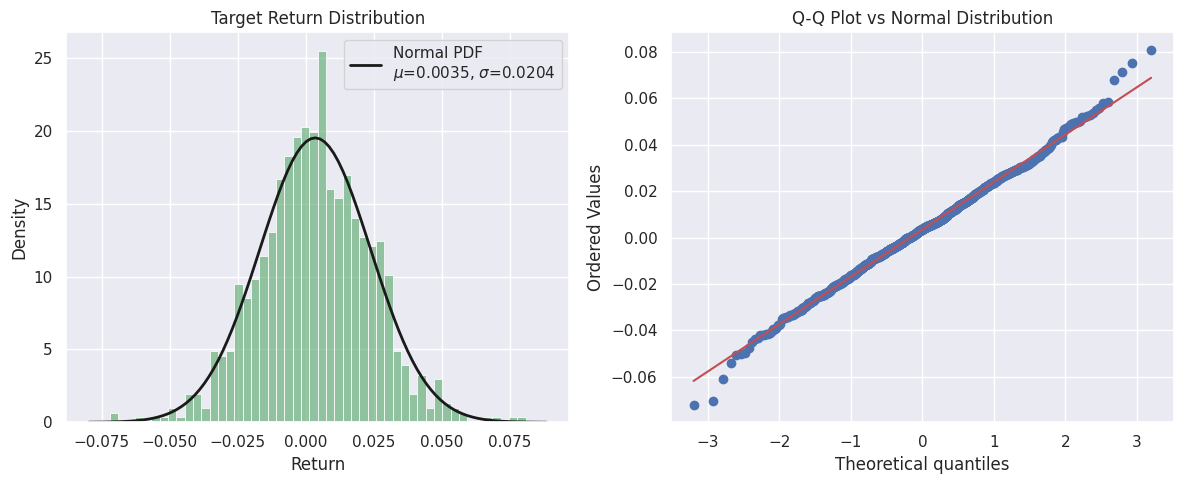

Skewness: 0.0294 (Normal = 0, <0 means negatively skewed)
Kurtosis (Fisher): 0.4792 (Normal = 0, >0 means fat tails / leptokurtic)


In [5]:
# Fit a normal distribution to the data
mu, std = norm.fit(y_train)

# Plot the histogram showing actual distribution vs theoretical Normal
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(y_train, bins=50, stat='density', alpha=0.6, color='g', ax=axs[0])

# Plot the PDF overlay
xmin, xmax = axs[0].get_xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
axs[0].plot(x, p, 'k', linewidth=2, label=f'Normal PDF\n$\mu$={mu:.4f}, $\sigma$={std:.4f}')
axs[0].set_title('Target Return Distribution')
axs[0].set_xlabel('Return')
axs[0].legend()

# QQ Plot to test for normality specifically at the tails
probplot(y_train, dist="norm", plot=axs[1])
axs[1].set_title('Q-Q Plot vs Normal Distribution')

plt.tight_layout()
plt.show()

# Print metrics testing for randomness properties
print(f"Skewness: {skew(y_train):.4f} (Normal = 0, <0 means negatively skewed)")
print(f"Kurtosis (Fisher): {kurtosis(y_train):.4f} (Normal = 0, >0 means fat tails / leptokurtic)")


## 3.75 "Dumb" Strategy Baselines
Before evaluating Machine Learning models, we should evaluate completely naïve strategies to establish a baseline Sharpe Ratio floor.
Since Sharpe ratio is scale-invariant, the basic scale of the position doesn't matter for pure static directional strategies.


In [26]:
def calc_sharpe(positions, returns):
    pnl = positions * returns
    return np.mean(pnl) / (np.std(pnl) + 1e-9) * 16

# Test baselines on the training set
# Strategy 1: Always Buy (Constant 1.0 position)
buy_all_pos = np.ones_like(y_train)

# Strategy 2: Always Sell (Constant -1.0 position)
sell_all_pos = -np.ones_like(y_train)

# Strategy 3: Random Guessing (Normal Distribution positions)
np.random.seed(42)
random_pos = np.random.randn(len(y_train))

# Strategy 4: Pure Momentum (Position directly proportional to Seen Return)
momentum_pos = X_train['seen_return'].values

# Strategy 5: Pure Mean Reversion (Position inversely proportional to Seen Return)
mean_reversion_pos = -X_train['seen_return'].values

# Strategy 6: Equal-Weighted Momentum (Only the sign matters, scale is locked at 1.0/-1.0)
eq_weight_momentum = np.sign(X_train['seen_return'].values)
eq_weight_momentum[eq_weight_momentum == 0] = 1.0

# Strategy 7: Perfect Forward Knowledge (God-Mode Optimal)
optimal_pos = y_train.values

# Strategy 8: Worst-Case Knowledge (Anti-God-Mode)
worst_pos = -y_train.values

# Strategy 9: Buy Losers Only (Buy if seen_return < 0, else do nothing)
buy_losers_pos = np.where(X_train['seen_return'].values < 0, 1.0, 0.0)

# Strategy 10: Buy Winners Only (Buy if seen_return > 0, else do nothing)
buy_winners_pos = np.where(X_train['seen_return'].values > 0, 1.0, 0.0)

print(f"1. 'Always Buy' Sharpe:           {calc_sharpe(buy_all_pos, y_train):.4f}")
print(f"2. 'Always Sell' Sharpe:          {calc_sharpe(sell_all_pos, y_train):.4f}")
print(f"3. 'Random Guessing' Sharpe:      {calc_sharpe(random_pos, y_train):.4f}")
print(f"4. 'Pure Momentum' Sharpe:        {calc_sharpe(momentum_pos, y_train):.4f}")
print(f"5. 'Pure Mean Reversion' Sharpe:  {calc_sharpe(mean_reversion_pos, y_train):.4f}")
print(f"6. 'EqW Momentum' Sharpe:         {calc_sharpe(eq_weight_momentum, y_train):.4f}")
print(f"9. 'Buy Losers Only' Sharpe:      {calc_sharpe(buy_losers_pos, y_train):.4f}")
print(f"\n--- Omniscient Bounds ---")
print(f"MAX. 'God-Mode Optimal' Sharpe:   {calc_sharpe(optimal_pos, y_train):.4f}")
print(f"MIN. 'Worst-Case Bounds' Sharpe:  {calc_sharpe(worst_pos, y_train):.4f}")


1. 'Always Buy' Sharpe:           2.7661
2. 'Always Sell' Sharpe:          -2.7661
3. 'Random Guessing' Sharpe:      -0.1093
4. 'Pure Momentum' Sharpe:        -0.8118
5. 'Pure Mean Reversion' Sharpe:  0.8118
6. 'EqW Momentum' Sharpe:         -0.1670
9. 'Buy Losers Only' Sharpe:      2.0857

--- Omniscient Bounds ---
MAX. 'God-Mode Optimal' Sharpe:   10.1820
MIN. 'Worst-Case Bounds' Sharpe:  -10.1820


## 4. Train Model
We will use a simple Random Forest Regressor to map the features to the expected target return.
The predicted expected return can act directly as our `target_position` (scaled up if necessary), because we want to take larger positions when we expect a larger return absolute value, and the sign indicates long/short.


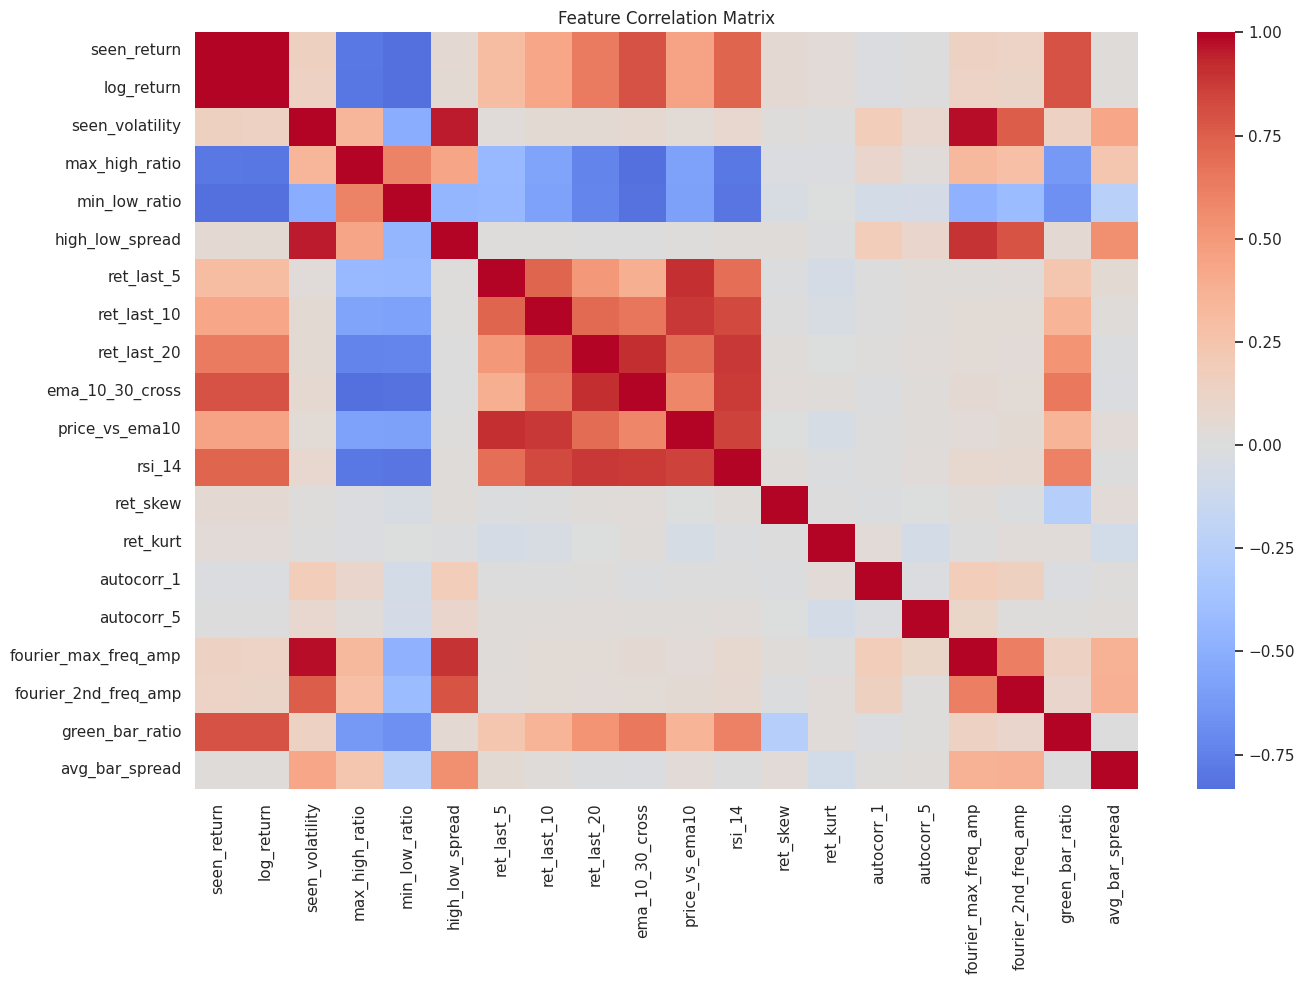

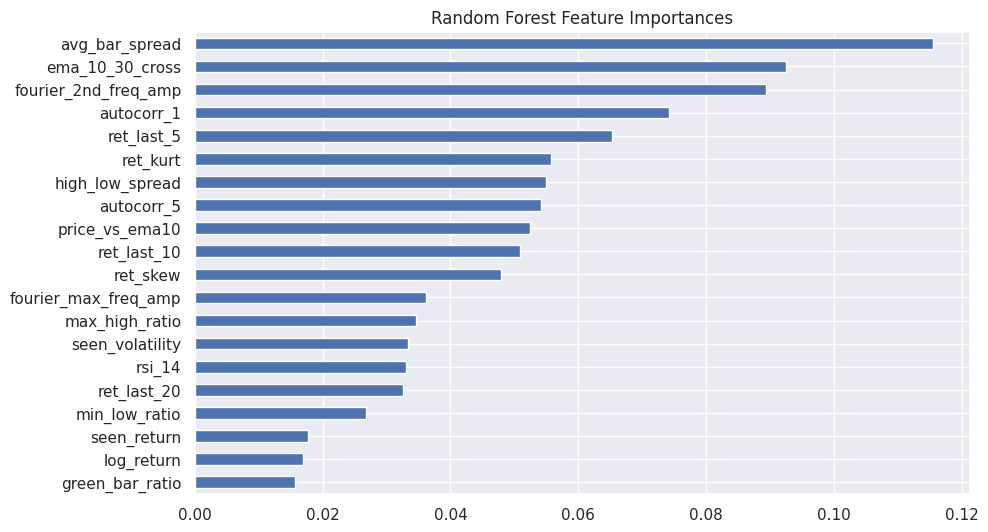

In [7]:
from sklearn.preprocessing import StandardScaler

# Handle any NaNs just in case
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

# Scale all features to have mean=0, std=1. This is critical for PyTorch / Linear Models
# so that the learned weights legitimately reflect feature importance, immune to scale.
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

# Plot Feature Correlation Heatmap
plt.figure(figsize=(14, 10))
corr_matrix = X_train_scaled.corr()
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Split into train and validation sets (80% train, 20% validation)
X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_tr, y_tr)

# View Feature Importances (Random Forest)
importances = pd.Series(model.feature_importances_, index=X_train_scaled.columns)
importances.sort_values().plot(kind='barh', title='Random Forest Feature Importances', figsize=(10, 6))
plt.show()


## 4.5 Direct Sharpe Ratio Optimization
Standard Machine Learning models (like Random Forest) try to minimize Mean Squared Error. However, since the competition metric is the Sharpe Ratio, we can use numerical optimization to find linear weights that *directly* maximize the Sharpe ratio on our training data!


In [8]:
from scipy.optimize import minimize

# Add intercept (bias) to the feature matrices
X_tr_opt = np.c_[np.ones(X_tr.shape[0]), X_tr]
X_val_opt = np.c_[np.ones(X_val.shape[0]), X_val]

def negative_sharpe(weights, X, returns):
    positions = np.dot(X, weights)
    pnl = positions * returns
    # Add epsilon to prevent division by zero
    sharpe = np.mean(pnl) / (np.std(pnl) + 1e-9)
    # Return negative Sharpe because scipy's minimize function actively seeks the lowest value
    return -sharpe

# Initial guess: all zeros, slight positive bias on seen_return to provide gradient direction
initial_weights = np.zeros(X_tr_opt.shape[1])
initial_weights[1] = 1.0 

# Run numeric optimization on the Training Fold
res = minimize(negative_sharpe, initial_weights, args=(X_tr_opt, y_tr), method='BFGS')
opt_weights = res.x

print("Optimized Linear Weights:", opt_weights)

# Evaluate on Train and Validation subsets
train_opt_preds = np.dot(X_tr_opt, opt_weights)
val_opt_preds = np.dot(X_val_opt, opt_weights)

opt_pnl_train = train_opt_preds * y_tr
opt_pnl_val = val_opt_preds * y_val

print(f"\nDIRECT SHARPE MODEL Training Sharpe: {np.mean(opt_pnl_train)/np.std(opt_pnl_train)*16:.4f}")
print(f"DIRECT SHARPE MODEL Validation Sharpe: {np.mean(opt_pnl_val)/np.std(opt_pnl_val)*16:.4f}")


Optimized Linear Weights: [ 1.12983567e-01  1.79476932e+00 -1.83622510e+00 -5.33279562e-03
 -3.83450155e-02 -7.05998600e-02  3.68008893e-02 -1.47883257e-02
 -3.22430381e-02 -3.94360762e-02  1.92070764e-02  1.34824987e-01
 -1.44974365e-01  1.51311326e-02 -4.50005725e-04  4.91272147e-03
 -2.74135983e-02 -5.39845315e-02 -4.44455460e-02 -3.48182772e-03
  1.26025339e-02]

DIRECT SHARPE MODEL Training Sharpe: 3.4377
DIRECT SHARPE MODEL Validation Sharpe: 2.5460


## 4.6 Automatic Differentiation (AD) with PyTorch
We can also directly optimize the Sharpe Ratio using an Automatic Differentiation (AD) framework like PyTorch.
By defining our model and the Sharpe calculation purely with PyTorch tensors, we can call `.backward()` and let the AD engine compute the exact analytical gradients of the Sharpe equation with respect to our model's weights!


Training PyTorch AD Model to directly maximize Sharpe...
Epoch 100/500 | Loss (Negative Sharpe): -0.2107


Epoch 200/500 | Loss (Negative Sharpe): -0.2115
Epoch 300/500 | Loss (Negative Sharpe): -0.2021
Epoch 400/500 | Loss (Negative Sharpe): -0.2124
Epoch 500/500 | Loss (Negative Sharpe): -0.2118

PyTorch AD Final Weights: [-7.34657198e-02 -1.13756888e-01  3.99888232e-02 -1.36942998e-01
 -3.49892646e-01  1.96158558e-01  2.94977762e-02 -1.18093207e-01
 -1.71314001e-01 -3.80267715e-03  3.15002084e-01 -3.20313126e-01
  3.55480053e-02 -4.59709018e-03  2.94656376e-04 -1.14734955e-01
 -2.63520449e-01 -1.90663144e-01 -7.00790286e-02  1.30507722e-02] Bias: 0.44155389070510864


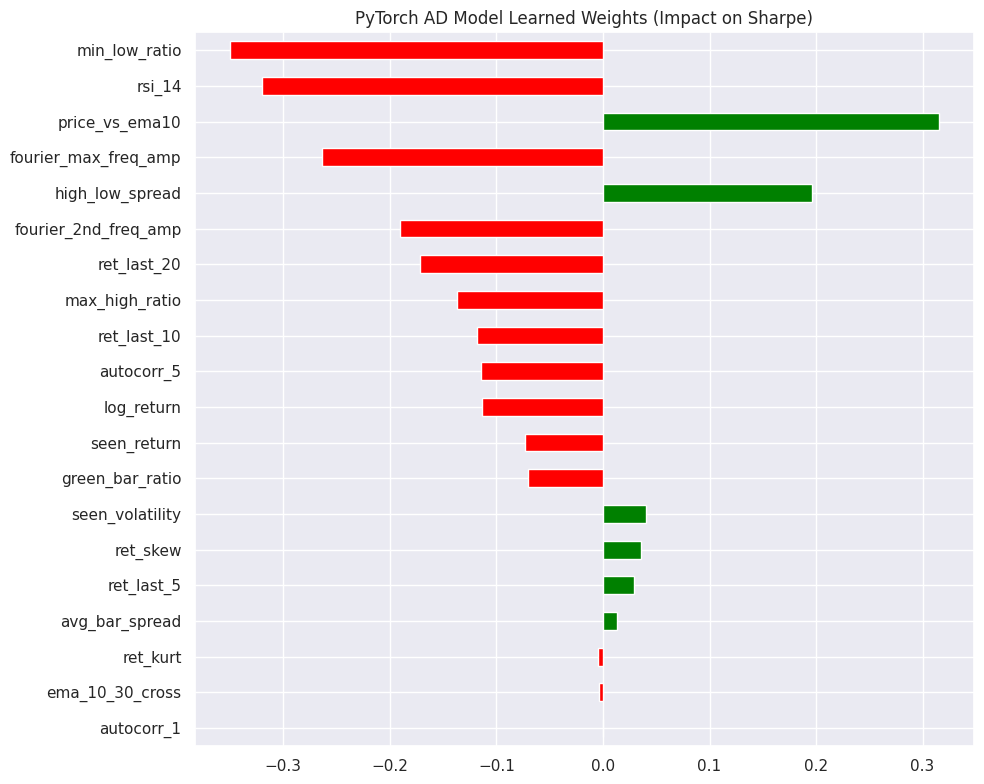


PyTorch AD Model Validation Sharpe: 2.7364


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

# Convert data to PyTorch tensors
X_pt = torch.tensor(X_tr.values, dtype=torch.float32)
y_pt = torch.tensor(y_tr.values, dtype=torch.float32)

# Define a simple linear model
class LinearSharpeModel(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.linear = nn.Linear(n_features, 1)
        # Initialize with slight positive weight on the 'seen_return' feature
        with torch.no_grad():
            self.linear.weight.zero_()
            self.linear.weight[0, 0] = 1.0  # (0 is now seen_return if sorted)
            self.linear.bias.zero_()
        
    def forward(self, x):
        return self.linear(x).squeeze()

# Instantiate model and Optimizer
ad_model = LinearSharpeModel(X_pt.shape[1])
# Added Ridge Regression (L2 Penalty) via weight_decay
optimizer = optim.Adam(ad_model.parameters(), lr=0.1, weight_decay=0.01)

print("Training PyTorch AD Model to directly maximize Sharpe...")
# Training loop
epochs = 500
for epoch in range(epochs):
    optimizer.zero_grad()
    
    # Forward pass: predict target positions
    positions = ad_model(X_pt)
    
    # Calculate PnL per session
    pnl = positions * y_pt
    
    # AD-compatible pseudo-Sharpe Loss (Minimize negative Sharpe)
    sharpe = torch.mean(pnl) / (torch.std(pnl) + 1e-6)
    loss = -sharpe
    
    # Automatic Differentiation MAGIC! Differentiates the final Sharpe ratio calculation.
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Loss (Negative Sharpe): {loss.item():.4f}")

# Extract weights safely
ad_weights = ad_model.linear.weight.detach().numpy().flatten()
ad_bias = ad_model.linear.bias.item()
print("\nPyTorch AD Final Weights:", ad_weights, "Bias:", ad_bias)

# Plot PyTorch AD Discovered Weights!
plt.figure(figsize=(10, 8))
ad_importances = pd.Series(ad_weights, index=X_train.columns)
# Sort by absolute value for cleanest impact view
ad_importances.sort_values(key=abs).plot(kind='barh', color=np.where(ad_importances.sort_values(key=abs) > 0, 'green', 'red'))
plt.title('PyTorch AD Model Learned Weights (Impact on Sharpe)')
plt.tight_layout()
plt.show()

# Evaluate on Validation subset
with torch.no_grad():
    X_val_pt = torch.tensor(X_val.values, dtype=torch.float32)
    val_preds_pt = ad_model(X_val_pt).numpy()
    
pnl_val_ad = val_preds_pt * y_val
val_sharpe_ad = np.mean(pnl_val_ad) / np.std(pnl_val_ad) * 16

print(f"\nPyTorch AD Model Validation Sharpe: {val_sharpe_ad:.4f}")


## 5. Generate Predictions

Train R2: 0.2645 | Val R2: 0.0400
Train MSE: 0.000308 | Val MSE: 0.000396

In-sample Estimated Sharpe Ratio: 5.9291
Validation Estimated Sharpe Ratio: 4.0666


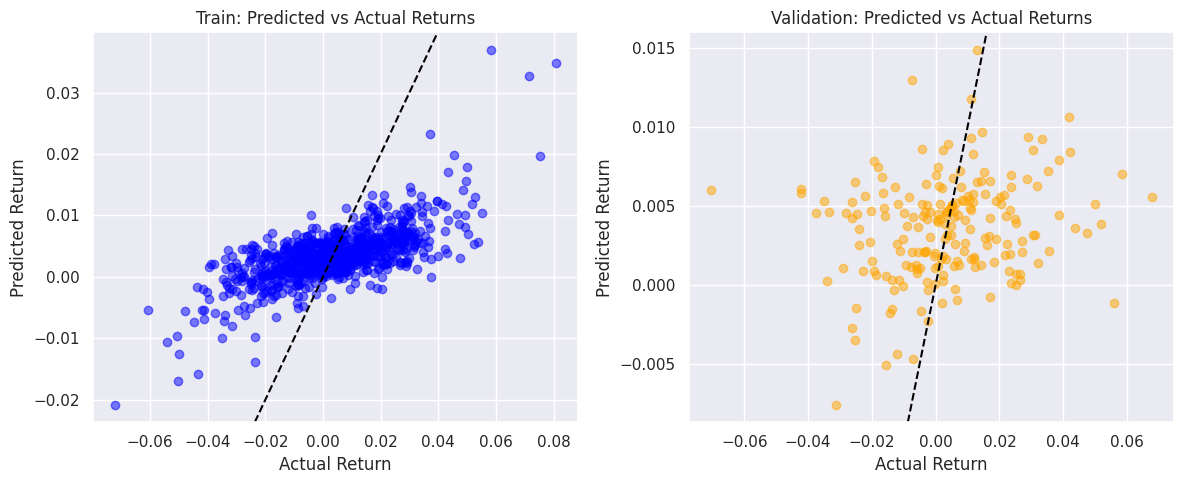

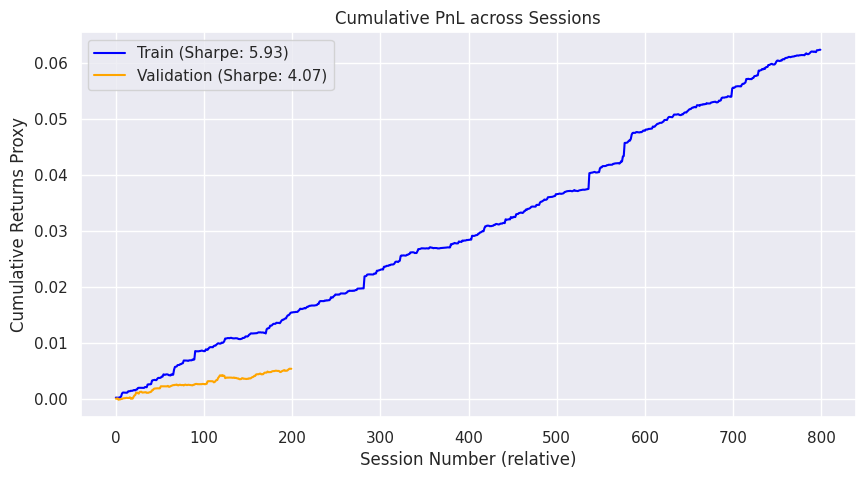


Generating test-set predictions from PyTorch AD Model for submission...


,session,target_position
0,1000,-17966.728516
1,1001,-14687.231445
2,1002,-15799.874023
3,1003,-11779.290039
4,1004,-16008.712891


In [10]:
# Predict expected returns
train_preds = model.predict(X_tr)
val_preds = model.predict(X_val)

# Metrics
train_r2 = r2_score(y_tr, train_preds)
val_r2 = r2_score(y_val, val_preds)

train_mse = mean_squared_error(y_tr, train_preds)
val_mse = mean_squared_error(y_val, val_preds)

print(f"Train R2: {train_r2:.4f} | Val R2: {val_r2:.4f}")
print(f"Train MSE: {train_mse:.6f} | Val MSE: {val_mse:.6f}\n")

# Calculate in-sample pseudo-Sharpe
pnl_train = train_preds * y_tr
in_sample_sharpe = np.mean(pnl_train) / np.std(pnl_train) * 16
print(f"In-sample Estimated Sharpe Ratio: {in_sample_sharpe:.4f}")

# Predict on validation fold
pnl_val = val_preds * y_val
val_sharpe = np.mean(pnl_val) / np.std(pnl_val) * 16
print(f"Validation Estimated Sharpe Ratio: {val_sharpe:.4f}")

# Plotting Predicted vs Actual
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].scatter(y_tr, train_preds, alpha=0.5, color='blue')
axs[0].axline((0, 0), slope=1, color='black', linestyle='--')
axs[0].set_title('Train: Predicted vs Actual Returns')
axs[0].set_xlabel('Actual Return')
axs[0].set_ylabel('Predicted Return')

axs[1].scatter(y_val, val_preds, alpha=0.5, color='orange')
axs[1].axline((0, 0), slope=1, color='black', linestyle='--')
axs[1].set_title('Validation: Predicted vs Actual Returns')
axs[1].set_xlabel('Actual Return')
axs[1].set_ylabel('Predicted Return')

plt.tight_layout()
plt.show()

# Plot Cumulative PnL Curve
plt.figure(figsize=(10, 5))
plt.plot(np.cumsum(pnl_train.values), label=f'Train (Sharpe: {in_sample_sharpe:.2f})', color='blue')
plt.plot(np.cumsum(pnl_val.values), label=f'Validation (Sharpe: {val_sharpe:.2f})', color='orange')
plt.title("Cumulative PnL across Sessions")
plt.ylabel("Cumulative Returns Proxy")
plt.xlabel("Session Number (relative)")
plt.legend()
plt.show()

# Create submission using the PyTorch AD Model!
X_test_pt = torch.tensor(X_test.values, dtype=torch.float32)

print("\nGenerating test-set predictions from PyTorch AD Model for submission...")
with torch.no_grad():
    test_preds_ad = ad_model(X_test_pt).numpy()

# Create submission (we scale it up arbitrary by 1000 for nicer position sizes)
submission = pd.DataFrame({
    'session': X_test.index,
    'target_position': test_preds_ad * 1000
})

submission.to_csv('submission.csv', index=False)
submission.head()
